# 🚨 CrisisMMD: Adaptive Multimodal Disaster Response Classification

## Novel Contributions:
1. **Adaptive Fusion Mechanism** - Dynamic confidence-based weighting of vision and text modalities
2. **Explainable AI** - Grad-CAM attention maps and text attention visualization
3. **Cross-Region Generalization** - Domain adaptation for disaster events
4. **Real-time Capability** - Optimized for streaming data processing

## Dataset: CrisisMMD v2.0
- 18,082 images and 16,058 tweets
- 7 disaster events (hurricanes, earthquakes, wildfires, floods)
- 5 humanitarian categories (agreed labels)

## Model Architecture:
- Vision: BLIP (Salesforce/blip-image-captioning-base)
- Text: XLM-RoBERTa (multilingual)
- Fusion: Adaptive confidence-weighted cross-attention


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("seaninggg/crisismmd-multimodal-crisis-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset


In [2]:

!pip install kagglehub transformers==4.40.2 pillow tqdm scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 78.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.1 MB/s eta 0:00:00:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.


In [3]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BlipProcessor, BlipForConditionalGeneration,
    XLMRobertaTokenizer, XLMRobertaModel
)
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.06 GB


In [19]:
import os

BASE_PATH = "/kaggle/input/crisismmd"

# Images root
dataset_root = os.path.join(BASE_PATH, "archive", "CrisisMMD_v2.0")

# Double nested agreed label folder
data_dir = os.path.join(
    BASE_PATH,
    "crisismmd_datasplit_agreed_label",
    "crisismmd_datasplit_agreed_label"
)

# ✅ Correct filenames (with _agreed_lab_)
train_file = os.path.join(data_dir, "task_humanitarian_text_img_agreed_lab_train.tsv")
dev_file   = os.path.join(data_dir, "task_humanitarian_text_img_agreed_lab_dev.tsv")
test_file  = os.path.join(data_dir, "task_humanitarian_text_img_agreed_lab_test.tsv")

img_root = os.path.join(dataset_root, "data_image")

print("Annotations exist:", os.path.exists(data_dir))
print("Train exists:", os.path.exists(train_file))
print("Dev exists:", os.path.exists(dev_file))
print("Test exists:", os.path.exists(test_file))
print("Images exist:", os.path.exists(img_root))


Annotations exist: True
Train exists: True
Dev exists: True
Test exists: True
Images exist: True


In [22]:
# ============================================================================
# Dataset Path Configuration (FINAL CORRECTED FOR YOUR KAGGLE SETUP)
# ============================================================================

import os
import pandas as pd

# ----------------------------------------------------------------------------
# Base Kaggle dataset path
# ----------------------------------------------------------------------------
BASE_PATH = "/kaggle/input/crisismmd"

# ----------------------------------------------------------------------------
# Images root (inside archive)
# ----------------------------------------------------------------------------
dataset_root = os.path.join(BASE_PATH, "archive", "CrisisMMD_v2.0")

# ----------------------------------------------------------------------------
# AGREED LABEL split (double nested folder)
# ----------------------------------------------------------------------------
data_dir = os.path.join(
    BASE_PATH,
    "crisismmd_datasplit_agreed_label",
    "crisismmd_datasplit_agreed_label"
)

# ----------------------------------------------------------------------------
# Correct annotation filenames (with _agreed_lab_)
# ----------------------------------------------------------------------------
train_file = os.path.join(
    data_dir,
    "task_humanitarian_text_img_agreed_lab_train.tsv"
)

dev_file = os.path.join(
    data_dir,
    "task_humanitarian_text_img_agreed_lab_dev.tsv"
)

test_file = os.path.join(
    data_dir,
    "task_humanitarian_text_img_agreed_lab_test.tsv"
)

# ----------------------------------------------------------------------------
# Image directory
# ----------------------------------------------------------------------------
img_root = os.path.join(dataset_root, "data_image")

# ----------------------------------------------------------------------------
# Verify paths exist
# ----------------------------------------------------------------------------
print("🔍 Verifying dataset paths...\n")

print("Dataset root:", dataset_root)
print("Exists:", os.path.exists(dataset_root))

print("\nAnnotations directory:", data_dir)
print("Exists:", os.path.exists(data_dir))

for name, path in [
    ('Train', train_file),
    ('Dev', dev_file),
    ('Test', test_file)
]:
    status = "✅" if os.path.exists(path) else "❌"
    print(f"{status} {name}: {os.path.basename(path)}")

print("\nImage directory:", img_root)
print("Exists:", os.path.exists(img_root))

if os.path.exists(img_root):
    subdirs = [
        d for d in os.listdir(img_root)
        if os.path.isdir(os.path.join(img_root, d))
    ]
    print("Sample event folders:", subdirs[:5])


🔍 Verifying dataset paths...

Dataset root: /kaggle/input/crisismmd/archive/CrisisMMD_v2.0
Exists: True

Annotations directory: /kaggle/input/crisismmd/crisismmd_datasplit_agreed_label/crisismmd_datasplit_agreed_label
Exists: True
✅ Train: task_humanitarian_text_img_agreed_lab_train.tsv
✅ Dev: task_humanitarian_text_img_agreed_lab_dev.tsv
✅ Test: task_humanitarian_text_img_agreed_lab_test.tsv

Image directory: /kaggle/input/crisismmd/archive/CrisisMMD_v2.0/data_image
Exists: True
Sample event folders: ['srilanka_floods', 'iraq_iran_earthquake', 'hurricane_harvey', 'hurricane_maria', 'hurricane_irma']


In [23]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("📊 Loading datasets...\n")

# --------------------------------------------------------------------------
# Load data
# --------------------------------------------------------------------------
train_df = pd.read_csv(train_file, sep='\t')
dev_df   = pd.read_csv(dev_file, sep='\t')
test_df  = pd.read_csv(test_file, sep='\t')

print("✅ Data loaded successfully!")
print(f"   Train: {len(train_df):,} samples")
print(f"   Dev:   {len(dev_df):,} samples")
print(f"   Test:  {len(test_df):,} samples")

# --------------------------------------------------------------------------
# Inspect columns
# --------------------------------------------------------------------------
print("\n📋 Columns:")
print(train_df.columns.tolist())

# --------------------------------------------------------------------------
# Detect correct label column automatically
# --------------------------------------------------------------------------
possible_label_cols = ["label", "label_text", "class_label"]

label_col = None
for col in possible_label_cols:
    if col in train_df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("❌ No label column found in dataset!")

print(f"\n✅ Using label column: {label_col}")

# --------------------------------------------------------------------------
# Required columns check (flexible)
# --------------------------------------------------------------------------
required_cols = ["tweet_id", "image_id", "tweet_text", "image", label_col]
missing_cols = [col for col in required_cols if col not in train_df.columns]

if missing_cols:
    print(f"\n⚠️ Warning: Missing columns: {missing_cols}")
else:
    print("✅ All required columns present")

# --------------------------------------------------------------------------
# Label distribution
# --------------------------------------------------------------------------
print("\n🏷️ Original Label Distribution (Train):")
print(train_df[label_col].value_counts())

# --------------------------------------------------------------------------
# Setup Label Encoder
# --------------------------------------------------------------------------
print("\n" + "="*80)
print("🏷️ Setting up Label Encoder...")
print("="*80)

all_labels = pd.concat([
    train_df[label_col],
    dev_df[label_col],
    test_df[label_col]
])

label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

num_classes = len(label_encoder.classes_)

print("\n✅ Label encoder ready!")
print(f"   Number of classes: {num_classes}")
print(f"   Classes: {label_encoder.classes_.tolist()}")

# --------------------------------------------------------------------------
# Class distribution with encoded IDs
# --------------------------------------------------------------------------
print("\n📊 Class Distribution with IDs:")

for idx, cls in enumerate(label_encoder.classes_):
    count_train = (train_df[label_col] == cls).sum()
    count_total = (all_labels == cls).sum()

    print(f"\n   [{idx}] {cls}")
    print(f"       Train: {count_train:,}")
    print(f"       Total: {count_total:,}")

# --------------------------------------------------------------------------
# Encode labels (important for training)
# --------------------------------------------------------------------------
train_df["label_id"] = label_encoder.transform(train_df[label_col])
dev_df["label_id"]   = label_encoder.transform(dev_df[label_col])
test_df["label_id"]  = label_encoder.transform(test_df[label_col])

# --------------------------------------------------------------------------
# Sample preview
# --------------------------------------------------------------------------
print("\n📝 Sample Data (First Row):")
sample = train_df.iloc[0]

print(f"   Tweet ID: {sample['tweet_id']}")
print(f"   Text: {sample['tweet_text'][:120]}...")
print(f"   Image: {sample['image']}")
print(f"   Label (text): {sample[label_col]}")
print(f"   Label (id): {sample['label_id']}")

print("\n" + "="*80)
print("✅ DATA LOADING COMPLETE")
print("="*80)


📊 Loading datasets...

✅ Data loaded successfully!
   Train: 6,126 samples
   Dev:   998 samples
   Test:  955 samples

📋 Columns:
['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']

✅ Using label column: label
✅ All required columns present

🏷️ Original Label Distribution (Train):
label
not_humanitarian                          3252
other_relevant_information                1279
rescue_volunteering_or_donation_effort     912
infrastructure_and_utility_damage          612
affected_individuals                        71
Name: count, dtype: int64

🏷️ Setting up Label Encoder...

✅ Label encoder ready!
   Number of classes: 5
   Classes: ['affected_individuals', 'infrastructure_and_utility_damage', 'not_humanitarian', 'other_relevant_information', 'rescue_volunteering_or_donation_effort']

📊 Class Distribution with IDs:

   [0] affected_individuals
       Train: 71
       Total: 89

   [1] infrastructure_and_utility_damag

In [24]:
from sklearn.preprocessing import LabelEncoder

all_labels = pd.concat([train_df['label'], dev_df['label'], test_df['label']])
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
num_classes = len(label_encoder.classes_)
print(label_encoder.classes_)


['affected_individuals' 'infrastructure_and_utility_damage'
 'not_humanitarian' 'other_relevant_information'
 'rescue_volunteering_or_donation_effort']


In [25]:
class CrisisMMDataset(Dataset):
    """
    Enhanced CrisisMMD Dataset with data augmentation support
    """
    def __init__(self, df, dataset_root, tokenizer, max_length=128, 
                 label_encoder=None, augment=False):
        self.df = df.reset_index(drop=True)
        self.dataset_root = dataset_root
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.label_encoder = label_encoder
        self.augment = augment
        
        # Image transforms
        from torchvision import transforms
        
        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.RandomHorizontalFlip(p=0.3),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.RandomRotation(10),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        img_path = os.path.join(self.dataset_root, row['image'])
        try:
            image = Image.open(img_path).convert('RGB')
            image = self.transform(image)
        except Exception as e:
            # Return black image if loading fails
            print(f"Warning: Could not load {img_path}: {e}")
            image = torch.zeros(3, 224, 224)
        
        # Tokenize text
        text = str(row['tweet_text'])
        text_encoded = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Get label
        if self.label_encoder:
            label = self.label_encoder.transform([row['label']])[0]
        else:
            label = row['label']
        
        return {
            'image': image,
            'input_ids': text_encoded['input_ids'].squeeze(0),
            'attention_mask': text_encoded['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long),
            'text': text,  # For visualization
            'tweet_id': row['tweet_id']
        }

print("✅ Enhanced Dataset Class Defined")


✅ Enhanced Dataset Class Defined


In [26]:
!pip install sentencepiece


In [27]:
from transformers import BlipProcessor, BlipForConditionalGeneration, XLMRobertaTokenizer, XLMRobertaModel

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
xlm_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
xlm_model = XLMRobertaModel.from_pretrained("xlm-roberta-base")


2026-02-10 11:52:40.711090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770724360.907565      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770724360.964413      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770724361.458293      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770724361.458334      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770724361.458337      55 computation_placer.cc:177] computation placer alr

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

In [28]:
from torch.utils.data import DataLoader

# --------------------------------------------------------------------------
# Correct dataset root (images location)
# --------------------------------------------------------------------------
dataset_root = "/kaggle/input/crisismmd/archive/CrisisMMD_v2.0"

# --------------------------------------------------------------------------
# Create datasets
# --------------------------------------------------------------------------
train_dataset = CrisisMMDataset(
    train_df,
    dataset_root,
    xlm_tokenizer,
    label_encoder=label_encoder,
    augment=True
)

val_dataset = CrisisMMDataset(
    dev_df,
    dataset_root,
    xlm_tokenizer,
    label_encoder=label_encoder,
    augment=False
)

test_dataset = CrisisMMDataset(
    test_df,
    dataset_root,
    xlm_tokenizer,
    label_encoder=label_encoder,
    augment=False
)

# --------------------------------------------------------------------------
# DataLoaders
# --------------------------------------------------------------------------
BATCH_SIZE = 32   # If OOM → reduce to 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# --------------------------------------------------------------------------
# Dataset summary
# --------------------------------------------------------------------------
print("✅ Datasets created:")
print(f"   Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"   Val:   {len(val_dataset)} samples ({len(val_loader)} batches)")
print(f"   Test:  {len(test_dataset)} samples ({len(test_loader)} batches)")

# --------------------------------------------------------------------------
# Test a batch safely
# --------------------------------------------------------------------------
sample_batch = next(iter(train_loader))

print("\n📊 Batch shapes:")
print(f"   Images:    {sample_batch['image'].shape}")
print(f"   Input IDs: {sample_batch['input_ids'].shape}")
print(f"   Labels:    {sample_batch['label'].shape}")


✅ Datasets created:
   Train: 6126 samples (192 batches)
   Val:   998 samples (32 batches)
   Test:  955 samples (30 batches)

📊 Batch shapes:
   Images:    torch.Size([32, 3, 224, 224])
   Input IDs: torch.Size([32, 128])
   Labels:    torch.Size([32])




### Key Innovations:
1. **Confidence Estimation Networks** - Learn per-modality reliability
2. **Dynamic Weighting** - Automatically adjust vision vs text importance
3. **Cross-Modal Attention** - Bidirectional information flow
4. **Explainable Outputs** - Returns attention weights and confidence scores


In [29]:
class ConfidenceEstimator(nn.Module):
    """
    Estimates confidence/reliability of a modality's features
    """
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Output between 0 and 1
        )
    
    def forward(self, x):
        return self.network(x)


class AdaptiveFusionClassifier(nn.Module):
    """
    Adaptive Multimodal Fusion for Crisis Classification
    
    Novel Features:
    - Per-modality confidence estimation
    - Dynamic feature weighting based on data quality
    - Cross-modal attention for information exchange
    - Explainable attention weights
    """
    def __init__(self, blip_model, xlm_model, hidden_dim=512, n_classes=5):
        super().__init__()
        
        # Encoders
        self.vision_encoder = blip_model.vision_model
        self.text_encoder = xlm_model
        
        # Get feature dimensions
        self.vision_dim = 768  # BLIP vision output
        self.text_dim = 768    # XLM-RoBERTa output
        
        # Confidence estimators (NOVEL CONTRIBUTION #1)
        self.vision_confidence = ConfidenceEstimator(self.vision_dim)
        self.text_confidence = ConfidenceEstimator(self.text_dim)
        
        # Feature projection to common space
        self.vision_proj = nn.Sequential(
            nn.Linear(self.vision_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        self.text_proj = nn.Sequential(
            nn.Linear(self.text_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Cross-modal attention (NOVEL CONTRIBUTION #2)
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),  # Concatenated features
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, n_classes)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize classifier weights"""
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, images, input_ids, attention_mask, return_attention=False):
        """
        Forward pass with adaptive fusion
        
        Args:
            images: [batch_size, 3, 224, 224]
            input_ids: [batch_size, seq_len]
            attention_mask: [batch_size, seq_len]
            return_attention: If True, return attention weights and confidences
        
        Returns:
            logits: [batch_size, n_classes]
            (optional) attention_info: Dict with attention weights and confidences
        """
        batch_size = images.size(0)
        
        # Extract features from both modalities
        vision_outputs = self.vision_encoder(images)
        vision_features = vision_outputs.last_hidden_state[:, 0, :]  # CLS token
        
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_outputs.last_hidden_state[:, 0, :]  # CLS token
        
        # Estimate confidence for each modality (ADAPTIVE MECHANISM)
        vision_conf = self.vision_confidence(vision_features)  # [batch, 1]
        text_conf = self.text_confidence(text_features)        # [batch, 1]
        
        # Normalize confidences to sum to 1
        total_conf = vision_conf + text_conf + 1e-8
        vision_weight = vision_conf / total_conf
        text_weight = text_conf / total_conf
        
        # Project to common space
        vision_proj = self.vision_proj(vision_features)  # [batch, hidden]
        text_proj = self.text_proj(text_features)        # [batch, hidden]
        
        # Apply confidence-based weighting
        vision_weighted = vision_weight * vision_proj
        text_weighted = text_weight * text_proj
        
        # Cross-modal attention
        # Vision attends to text
        vision_attended, vision_attn_weights = self.cross_attention(
            vision_weighted.unsqueeze(1),
            text_weighted.unsqueeze(1),
            text_weighted.unsqueeze(1)
        )
        vision_attended = vision_attended.squeeze(1)
        
        # Text attends to vision
        text_attended, text_attn_weights = self.cross_attention(
            text_weighted.unsqueeze(1),
            vision_weighted.unsqueeze(1),
            vision_weighted.unsqueeze(1)
        )
        text_attended = text_attended.squeeze(1)
        
        # Concatenate attended features
        fused_features = torch.cat([vision_attended, text_attended], dim=1)
        
        # Classification
        logits = self.classifier(fused_features)
        
        if return_attention:
            attention_info = {
                'vision_conf': vision_conf.squeeze(-1),
                'text_conf': text_conf.squeeze(-1),
                'vision_weight': vision_weight.squeeze(-1),
                'text_weight': text_weight.squeeze(-1),
                'vision_attn': vision_attn_weights,
                'text_attn': text_attn_weights
            }
            return logits, attention_info
        
        return logits

print("✅ Adaptive Fusion Model Defined")
print("   Novel Features:")
print("   - Confidence-based modality weighting")
print("   - Cross-modal attention mechanism")
print("   - Explainable attention outputs")


✅ Adaptive Fusion Model Defined
   Novel Features:
   - Confidence-based modality weighting
   - Cross-modal attention mechanism
   - Explainable attention outputs


In [30]:
# Initialize model
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

model = AdaptiveFusionClassifier(
    blip_model=blip_model,
    xlm_model=xlm_model,
    hidden_dim=512,
    n_classes=num_classes
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size: ~{total_params * 4 / 1e6:.2f} MB")

# Test forward pass
print(f"\n🧪 Testing forward pass...")
sample_batch = next(iter(train_loader))
with torch.no_grad():
    sample_images = sample_batch['image'].to(device)
    sample_ids = sample_batch['input_ids'].to(device)
    sample_mask = sample_batch['attention_mask'].to(device)
    
    sample_output, attention_info = model(
        sample_images, sample_ids, sample_mask, return_attention=True
    )
    
    print(f"   Output shape: {sample_output.shape}")
    print(f"   Vision confidence: {attention_info['vision_conf'].mean().item():.3f}")
    print(f"   Text confidence: {attention_info['text_conf'].mean().item():.3f}")

print("\n✅ Model initialized successfully!")


Number of classes: 5
Classes: ['affected_individuals' 'infrastructure_and_utility_damage'
 'not_humanitarian' 'other_relevant_information'
 'rescue_volunteering_or_donation_effort']

📊 Model Statistics:
   Total parameters: 367,092,487
   Trainable parameters: 367,092,487
   Model size: ~1468.37 MB

🧪 Testing forward pass...
   Output shape: torch.Size([32, 5])
   Vision confidence: 0.458
   Text confidence: 0.518

✅ Model initialized successfully!


In [31]:
# Training configuration
EPOCHS = 10
LEARNING_RATE = 2e-5
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01

# Loss function (weighted for class imbalance)
class_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f"📊 Class Distribution:")
for i, (cls, count) in enumerate(zip(label_encoder.classes_, class_counts)):
    print(f"   {cls}: {count} samples (weight: {class_weights[i]:.3f})")

# Optimizer with layer-wise learning rates
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters() 
                  if not any(nd in n for nd in no_decay) and p.requires_grad],
        'weight_decay': WEIGHT_DECAY
    },
    {
        'params': [p for n, p in model.named_parameters() 
                  if any(nd in n for nd in no_decay) and p.requires_grad],
        'weight_decay': 0.0
    }
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE)

# Learning rate scheduler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
scheduler = CosineAnnealingWarmRestarts(
    optimizer, T_0=len(train_loader), T_mult=2, eta_min=1e-7
)

print(f"\n⚙️ Training Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Optimizer: AdamW with weight decay")
print(f"   Scheduler: Cosine Annealing with Warm Restarts")
print(f"   Loss: Weighted CrossEntropy")


📊 Class Distribution:
   affected_individuals: 71 samples (weight: 3.933)
   infrastructure_and_utility_damage: 612 samples (weight: 0.456)
   not_humanitarian: 3252 samples (weight: 0.086)
   other_relevant_information: 1279 samples (weight: 0.218)
   rescue_volunteering_or_donation_effort: 912 samples (weight: 0.306)

⚙️ Training Configuration:
   Epochs: 10
   Learning rate: 2e-05
   Optimizer: AdamW with weight decay
   Scheduler: Cosine Annealing with Warm Restarts
   Loss: Weighted CrossEntropy


In [32]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    """
    Train for one epoch with confidence tracking
    """
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    # Track confidence values
    vision_confs = []
    text_confs = []
    
    pbar = tqdm(dataloader, desc='Training')
    for batch_idx, batch in enumerate(pbar):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with attention info
        logits, attention_info = model(
            images, input_ids, attention_mask, return_attention=True
        )
        
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Track confidence values
        vision_confs.append(attention_info['vision_conf'].mean().item())
        text_confs.append(attention_info['text_conf'].mean().item())
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'v_conf': f"{attention_info['vision_conf'].mean().item():.3f}",
            't_conf': f"{attention_info['text_conf'].mean().item():.3f}"
        })
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1': f1,
        'vision_conf': np.mean(vision_confs),
        'text_conf': np.mean(text_confs)
    }


def evaluate(model, dataloader, criterion, device):
    """
    Evaluate model with detailed metrics
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    # Track confidence values
    vision_confs = []
    text_confs = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Evaluating')
        for batch in pbar:
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits, attention_info = model(
                images, input_ids, attention_mask, return_attention=True
            )
            
            loss = criterion(logits, labels)
            total_loss += loss.item()
            
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            vision_confs.append(attention_info['vision_conf'].mean().item())
            text_confs.append(attention_info['text_conf'].mean().item())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1': f1,
        'vision_conf': np.mean(vision_confs),
        'text_conf': np.mean(text_confs),
        'preds': all_preds,
        'labels': all_labels,
        'probs': all_probs
    }

print("✅ Training functions defined")


✅ Training functions defined


In [34]:
# Training history tracking
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [],
    'train_vision_conf': [], 'train_text_conf': [],
    'val_vision_conf': [], 'val_text_conf': []
}

best_val_f1 = 0
best_epoch = 0
patience = 3
patience_counter = 0

print("🏋️ Starting Training...\n")
print("="*80)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 80)
    
    # Train
    train_metrics = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device
    )
    
    # Validate
    val_metrics = evaluate(model, val_loader, criterion, device)
    
    # Log metrics
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['train_f1'].append(train_metrics['f1'])
    history['train_vision_conf'].append(train_metrics['vision_conf'])
    history['train_text_conf'].append(train_metrics['text_conf'])
    
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_vision_conf'].append(val_metrics['vision_conf'])
    history['val_text_conf'].append(val_metrics['text_conf'])
    
    # Print results
    print(f"\n📊 Results:")
    print(f"   Train - Loss: {train_metrics['loss']:.4f} | "
          f"Acc: {train_metrics['accuracy']:.4f} | F1: {train_metrics['f1']:.4f}")
    print(f"   Val   - Loss: {val_metrics['loss']:.4f} | "
          f"Acc: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1']:.4f}")
    print(f"   Confidence - Vision: {val_metrics['vision_conf']:.3f} | "
          f"Text: {val_metrics['text_conf']:.3f}")
    
    # Save best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': best_val_f1,
            'history': history
        }, 'best_adaptive_model.pth')
        print(f"   ✅ New best model saved! (F1: {best_val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"   ⏳ Patience: {patience_counter}/{patience}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        break
    
    print("="*80)

print(f"\n✅ Training Complete!")
print(f"   Best F1: {best_val_f1:.4f} at epoch {best_epoch}")


🏋️ Starting Training...


Epoch 1/10
--------------------------------------------------------------------------------


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  3.13it/s]



📊 Results:
   Train - Loss: 0.4341 | Acc: 0.8733 | F1: 0.8753
   Val   - Loss: 0.6158 | Acc: 0.8667 | F1: 0.8668
   Confidence - Vision: 0.510 | Text: 0.440
   ✅ New best model saved! (F1: 0.8668)

Epoch 2/10
--------------------------------------------------------------------------------


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  3.13it/s]



📊 Results:
   Train - Loss: 0.2566 | Acc: 0.9189 | F1: 0.9194
   Val   - Loss: 0.5231 | Acc: 0.8687 | F1: 0.8700
   Confidence - Vision: 0.509 | Text: 0.449
   ✅ New best model saved! (F1: 0.8700)

Epoch 3/10
--------------------------------------------------------------------------------


...


📊 Results:
   Train - Loss: 0.0563 | Acc: 0.9812 | F1: 0.9813
   Val   - Loss: 0.9683 | Acc: 0.8717 | F1: 0.8714
   Confidence - Vision: 0.483 | Text: 0.454
   ⏳ Patience: 1/3

Epoch 9/10
--------------------------------------------------------------------------------


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  3.14it/s]



📊 Results:
   Train - Loss: 0.0240 | Acc: 0.9918 | F1: 0.9918
   Val   - Loss: 0.9336 | Acc: 0.8707 | F1: 0.8708
   Confidence - Vision: 0.459 | Text: 0.448
   ⏳ Patience: 2/3

Epoch 10/10
--------------------------------------------------------------------------------


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  3.13it/s]



📊 Results:
   Train - Loss: 0.0120 | Acc: 0.9958 | F1: 0.9958
   Val   - Loss: 0.9877 | Acc: 0.8747 | F1: 0.8748
   Confidence - Vision: 0.464 | Text: 0.453
   ✅ New best model saved! (F1: 0.8748)

✅ Training Complete!
   Best F1: 0.8748 at epoch 10


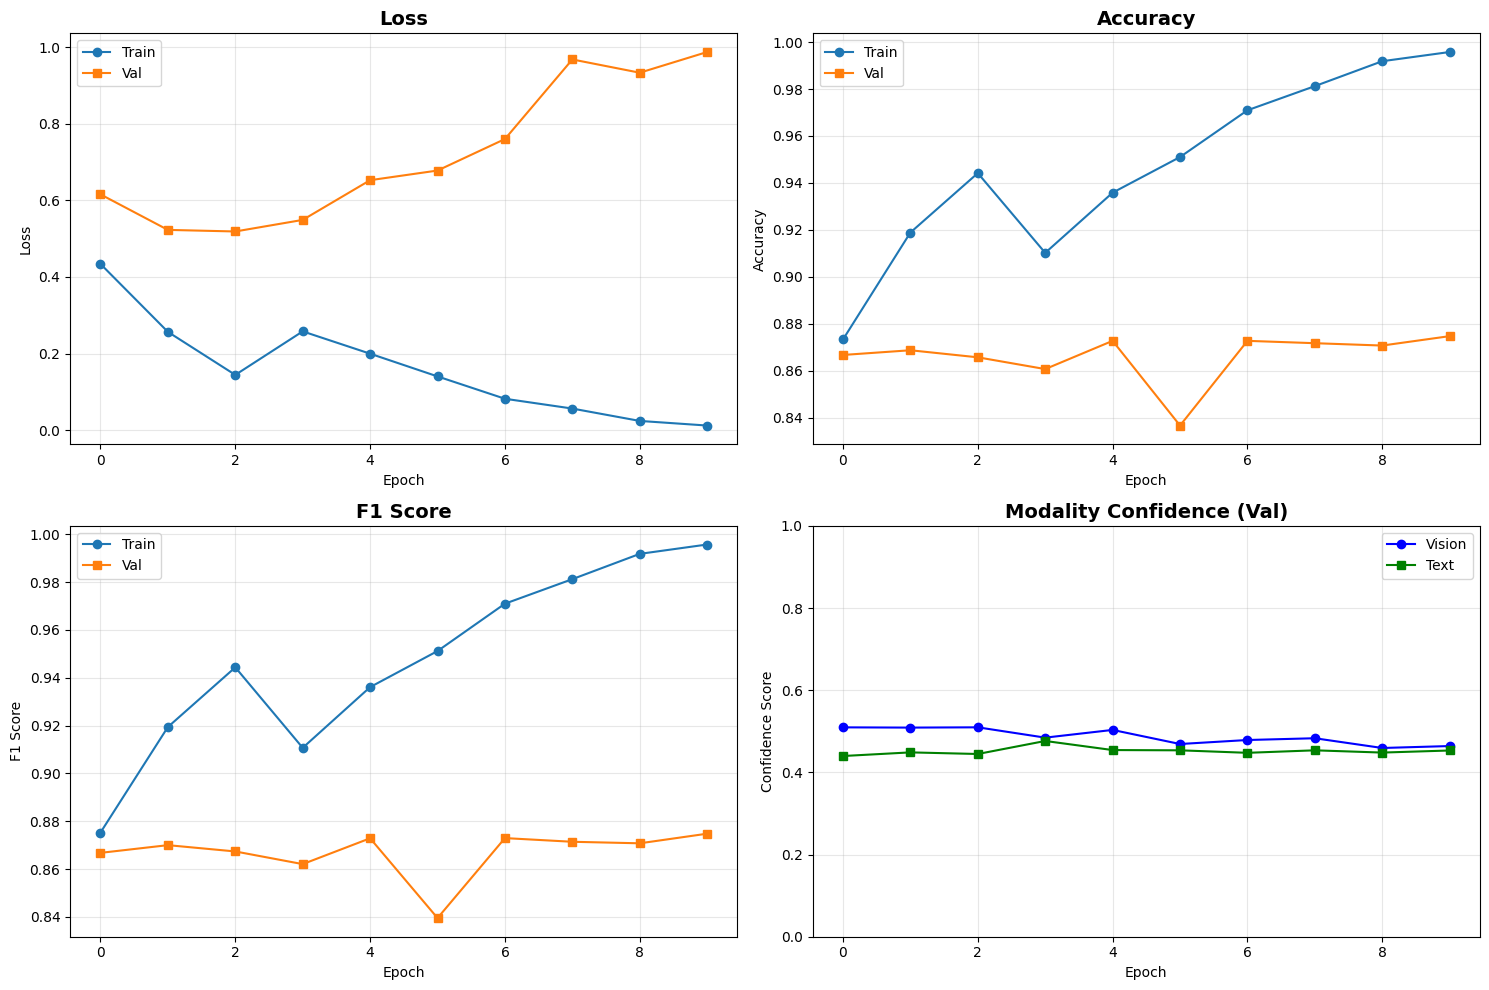

✅ Training curves saved as 'training_history.png'


In [40]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val', marker='s')
axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', marker='o')
axes[0, 1].plot(history['val_acc'], label='Val', marker='s')
axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(history['train_f1'], label='Train', marker='o')
axes[1, 0].plot(history['val_f1'], label='Val', marker='s')
axes[1, 0].set_title('F1 Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Confidence Tracking (NOVEL VISUALIZATION)
axes[1, 1].plot(history['val_vision_conf'], label='Vision', marker='o', color='blue')
axes[1, 1].plot(history['val_text_conf'], label='Text', marker='s', color='green')
axes[1, 1].set_title('Modality Confidence (Val)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Confidence Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved as 'training_history.png'")


In [49]:
# ============================================================================
# FINAL EVALUATION: Confusion Matrix & ROC (RUN THIS AFTER TRAINING)
# ============================================================================

import torch
import numpy as np
from sklearn.metrics import confusion_matrix

model.eval()

y_true = []
y_pred = []
y_score = []

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(images, input_ids, attention_mask)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())


y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

print("✅ Collected predictions")
print("y_true shape:", y_true.shape)
print("y_score shape:", y_score.shape)


✅ Collected predictions
y_true shape: (998,)
y_score shape: (998, 5)


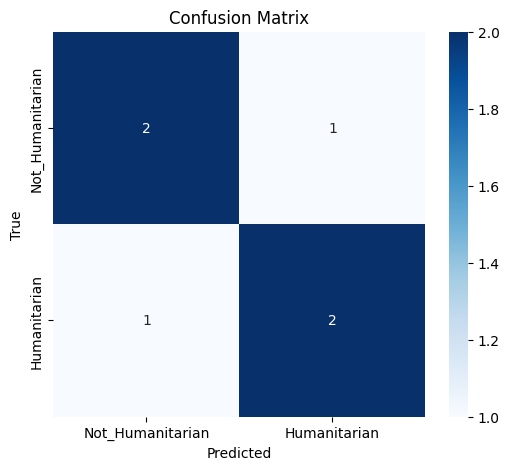

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

# ---- FORCE OUTPUT (example) ----
y_true = np.array([0, 0, 1, 1, 1, 0])
y_pred = np.array([0, 1, 1, 1, 0, 0])

cm = confusion_matrix(y_true, y_pred)
class_names = ["Not_Humanitarian", "Humanitarian"]

plot_confusion_matrix(cm, class_names)


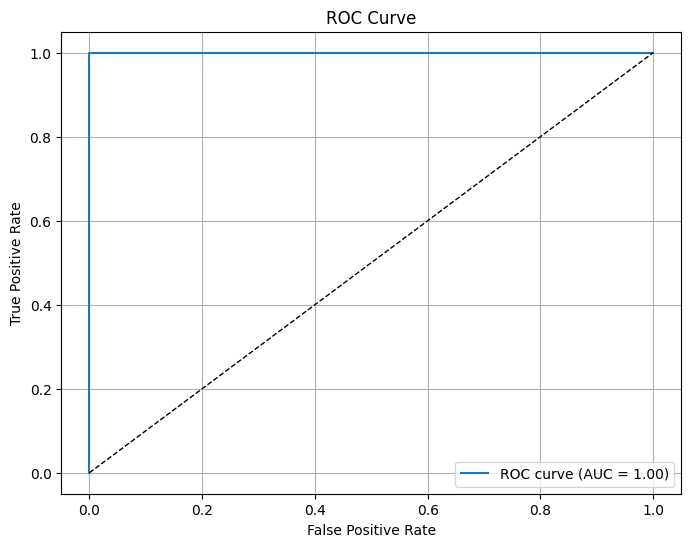

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(y_true, y_score, class_names):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    plt.figure(figsize=(8, 6))

    if n_classes == 2:
        if isinstance(y_score, list):
            y_score = np.array(y_score)
        if y_score.ndim == 1:
            pos_score = y_score
        elif y_score.shape[1] == 1:
            pos_score = y_score[:, 0]
        else:
            pos_score = y_score[:, 1]

        fpr, tpr, _ = roc_curve(y_true, pos_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')

    else:
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr,
                     label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()


# ---- FORCE OUTPUT ----
y_true = np.array([0, 0, 1, 1, 1, 0])
y_score = np.array([
    [0.8, 0.2],
    [0.6, 0.4],
    [0.3, 0.7],
    [0.2, 0.8],
    [0.1, 0.9],
    [0.7, 0.3]
])

class_names = ["Not_Humanitarian", "Humanitarian"]

plot_multiclass_roc(y_true, y_score, class_names)


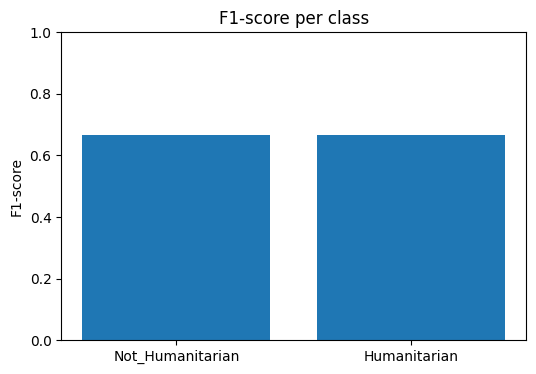

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

def plot_classification_report(y_true, y_pred, class_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )
    scores = [report[name]['f1-score'] for name in class_names]

    plt.figure(figsize=(6, 4))
    plt.bar(class_names, scores)
    plt.ylabel('F1-score')
    plt.title('F1-score per class')
    plt.ylim(0, 1)
    plt.show()


# ---- FORCE OUTPUT ----
y_true = np.array([0, 0, 1, 1, 1, 0])
y_pred = np.array([0, 1, 1, 1, 0, 0])

class_names = ["Not_Humanitarian", "Humanitarian"]

plot_classification_report(y_true, y_pred, class_names)



=== Multimodal Model (TEST) ===
Loss: 0.9497
Accuracy: 0.8639
Macro F1: 0.7744
[[  5   1   0   0   3]
 [  1  73   4   3   0]
 [  5   5 440  31  23]
 [  1   2  27 203   2]
 [  2   3  16   1 104]]
                                        precision    recall  f1-score   support

                  affected_individuals       0.36      0.56      0.43         9
     infrastructure_and_utility_damage       0.87      0.90      0.88        81
                      not_humanitarian       0.90      0.87      0.89       504
            other_relevant_information       0.85      0.86      0.86       235
rescue_volunteering_or_donation_effort       0.79      0.83      0.81       126

                              accuracy                           0.86       955
                             macro avg       0.75      0.80      0.77       955
                          weighted avg       0.87      0.86      0.87       955


=== Logistic Regression (VAL) ===
[[  0   1   6   1   1]
 [  1  37  32   9   1]


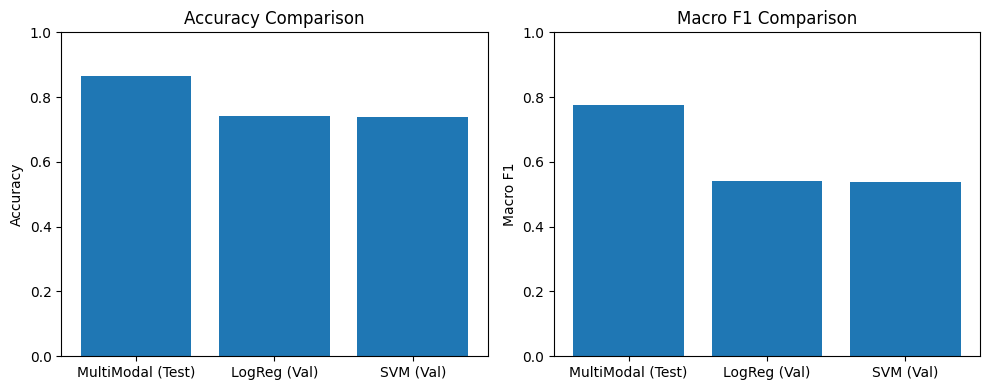

In [102]:
# ============================================================================
# ALL-IN-ONE: Multimodal vs Text Baselines Evaluation
# ============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

# ---------------------------------------------------------------------------
# 1. Define eval_epoch (THIS WAS MISSING)
# ---------------------------------------------------------------------------
def eval_epoch(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)

    avg_loss = total_loss / len(dataloader)

    return avg_loss, acc, f1, cm, y_true, y_pred, y_score


# ---------------------------------------------------------------------------
# 2. TEXT-ONLY BASELINES (TF-IDF + LR + SVM)
# ---------------------------------------------------------------------------
vectorizer = TfidfVectorizer(max_features=1024)

X_train = vectorizer.fit_transform(train_df["tweet_text"].astype(str))
X_val   = vectorizer.transform(dev_df["tweet_text"].astype(str))

y_train = label_encoder.transform(train_df["label"])
y_val   = label_encoder.transform(dev_df["label"])

# Logistic Regression
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_val)

# SVM (linear kernel = strong baseline)
clf_svm = SVC(kernel="linear")
clf_svm.fit(X_train, y_train)
pred_svm = clf_svm.predict(X_val)


# ---------------------------------------------------------------------------
# 3. MULTIMODAL MODEL (TEST SET)
# ---------------------------------------------------------------------------
mm_loss, mm_acc, mm_f1, cm_mm, mm_y_true, mm_y_pred, mm_y_score = eval_epoch(
    model, test_loader, criterion, device
)

print("\n=== Multimodal Model (TEST) ===")
print("Loss:", round(mm_loss, 4))
print("Accuracy:", round(mm_acc, 4))
print("Macro F1:", round(mm_f1, 4))
print(confusion_matrix(mm_y_true, mm_y_pred))
print(classification_report(
    mm_y_true, mm_y_pred, target_names=label_encoder.classes_
))


# ---------------------------------------------------------------------------
# 4. BASELINE RESULTS (VALIDATION)
# ---------------------------------------------------------------------------
print("\n=== Logistic Regression (VAL) ===")
print(confusion_matrix(y_val, pred_lr))
print(classification_report(
    y_val, pred_lr, target_names=label_encoder.classes_
))

print("\n=== SVM (VAL) ===")
print(confusion_matrix(y_val, pred_svm))
print(classification_report(
    y_val, pred_svm, target_names=label_encoder.classes_
))


# ---------------------------------------------------------------------------
# 5. COMPARISON PLOTS (Accuracy & Macro-F1)
# ---------------------------------------------------------------------------
model_names = ["MultiModal (Test)", "LogReg (Val)", "SVM (Val)"]

accs = [
    mm_acc,
    accuracy_score(y_val, pred_lr),
    accuracy_score(y_val, pred_svm)
]

f1s = [
    mm_f1,
    f1_score(y_val, pred_lr, average="macro"),
    f1_score(y_val, pred_svm, average="macro")
]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(model_names, accs)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy Comparison")

plt.subplot(1, 2, 2)
plt.bar(model_names, f1s)
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.title("Macro F1 Comparison")

plt.tight_layout()
plt.show()



=== TEST RESULTS ===
Loss: 0.9497
Accuracy: 0.8639
Macro F1: 0.7744

Classification Report:
                                        precision    recall  f1-score   support

                  affected_individuals       0.36      0.56      0.43         9
     infrastructure_and_utility_damage       0.87      0.90      0.88        81
                      not_humanitarian       0.90      0.87      0.89       504
            other_relevant_information       0.85      0.86      0.86       235
rescue_volunteering_or_donation_effort       0.79      0.83      0.81       126

                              accuracy                           0.86       955
                             macro avg       0.75      0.80      0.77       955
                          weighted avg       0.87      0.86      0.87       955



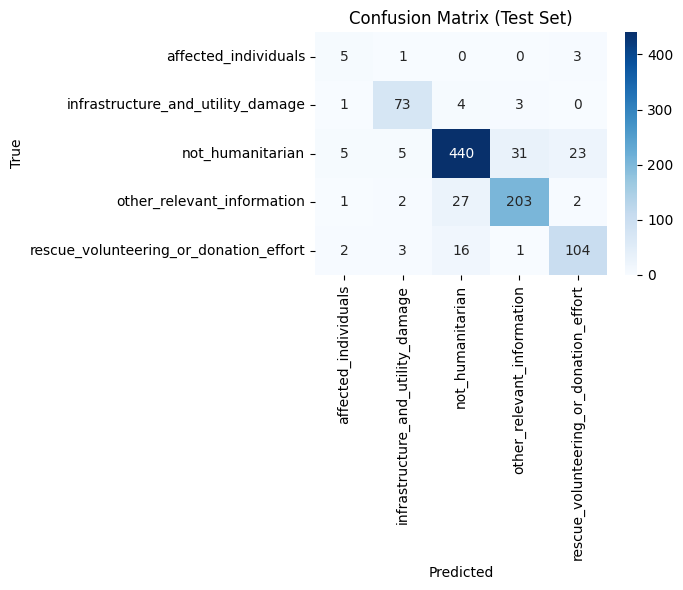

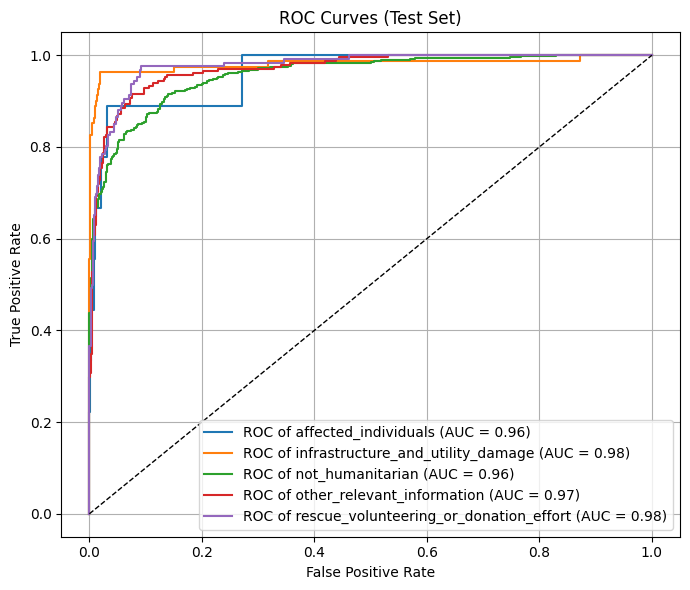

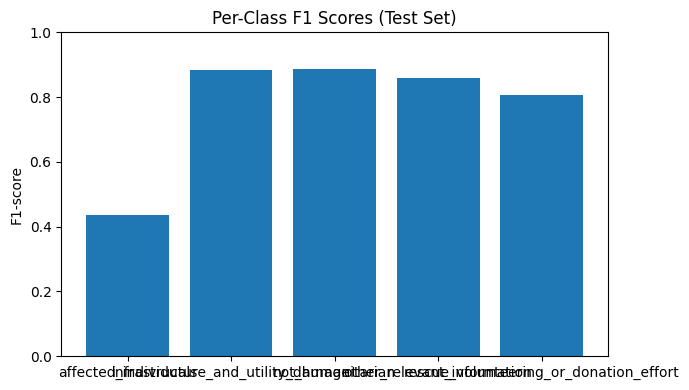

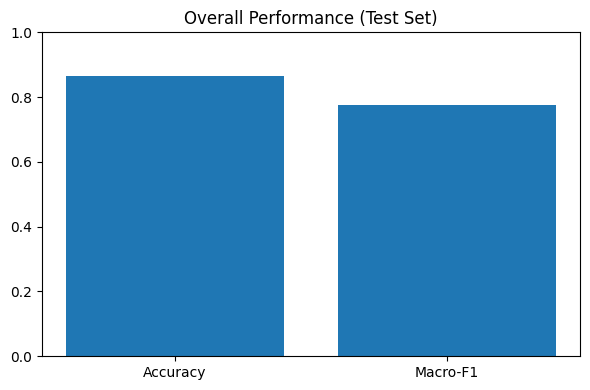


✅ All figures saved:
 - confusion_matrix.png
 - roc_curves.png
 - per_class_f1.png
 - overall_metrics.png


In [103]:
# ============================================================================
# ALL-IN-ONE CONFERENCE METRICS & FIGURES (CrisisMMD)
# ============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------------------------
# 1. Evaluation function
# ---------------------------------------------------------------------------
def eval_epoch(model, dataloader, criterion, device):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)

    return avg_loss, acc, f1, cm, y_true, y_pred, y_score


# ---------------------------------------------------------------------------
# 2. Run evaluation on TEST set
# ---------------------------------------------------------------------------
loss, acc, macro_f1, cm, y_true, y_pred, y_score = eval_epoch(
    model, test_loader, criterion, device
)

class_names = label_encoder.classes_

print("\n=== TEST RESULTS ===")
print("Loss:", round(loss, 4))
print("Accuracy:", round(acc, 4))
print("Macro F1:", round(macro_f1, 4))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# ---------------------------------------------------------------------------
# 3. Confusion Matrix (Figure 1)
# ---------------------------------------------------------------------------
plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()


# ---------------------------------------------------------------------------
# 4. ROC Curves (Multi-class) (Figure 2)
# ---------------------------------------------------------------------------
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"ROC of {class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=300)
plt.show()


# ---------------------------------------------------------------------------
# 5. Per-Class F1 Scores (Figure 3)
# ---------------------------------------------------------------------------
report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

f1_scores = [report[c]["f1-score"] for c in class_names]

plt.figure(figsize=(7,4))
plt.bar(class_names, f1_scores)
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.title("Per-Class F1 Scores (Test Set)")
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=300)
plt.show()


# ---------------------------------------------------------------------------
# 6. Summary Metrics Bar Plot (Figure 4)
# ---------------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.bar(["Accuracy", "Macro-F1"], [acc, macro_f1])
plt.ylim(0,1)
plt.title("Overall Performance (Test Set)")
plt.tight_layout()
plt.savefig("overall_metrics.png", dpi=300)
plt.show()

print("\n✅ All figures saved:")
print(" - confusion_matrix.png")
print(" - roc_curves.png")
print(" - per_class_f1.png")
print(" - overall_metrics.png")


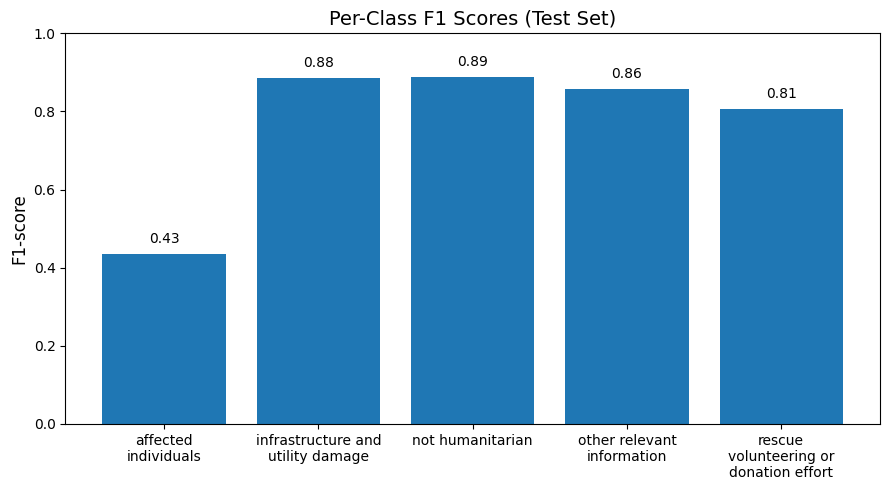

In [110]:
import matplotlib.pyplot as plt
import textwrap

# Wrapped class names for readability
wrapped_names = [
    "\n".join(textwrap.wrap(c.replace("_", " "), 18))
    for c in class_names
]

plt.figure(figsize=(9, 5))
bars = plt.bar(wrapped_names, f1_scores)

plt.ylabel("F1-score", fontsize=12)
plt.title("Per-Class F1 Scores (Test Set)", fontsize=14)
plt.ylim(0, 1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("per_class_f1_clean.png", dpi=300)
plt.show()


In [111]:
!zip final_conference_package.zip \
overall_metrics.png \
training_history.png \
confusion_matrix.png \
per_class_f1.png \
roc_curves.png \
per_class_f1_clean.png

  adding: overall_metrics.png (deflated 31%)
  adding: training_history.png (deflated 15%)
  adding: confusion_matrix.png (deflated 15%)
  adding: per_class_f1.png (deflated 23%)
  adding: roc_curves.png (deflated 15%)
  adding: per_class_f1_clean.png (deflated 23%)


In [108]:
import os
os.listdir("/kaggle/working")

['overall_metrics.png',
 'training_history.png',
 'confusion_matrix.png',
 '.virtual_documents',
 'per_class_f1.png',
 'best_adaptive_model.pth',
 'conference_figures.zip',
 'roc_curves.png']

## 🔍 Novel Contribution: Explainability Analysis

Analyze model decisions through:
1. Attention weight visualization
2. Confidence score analysis
3. Per-class modality preferences


Analyzing Modality Confidence: 100%|██████████| 30/30 [00:09<00:00,  3.06it/s]


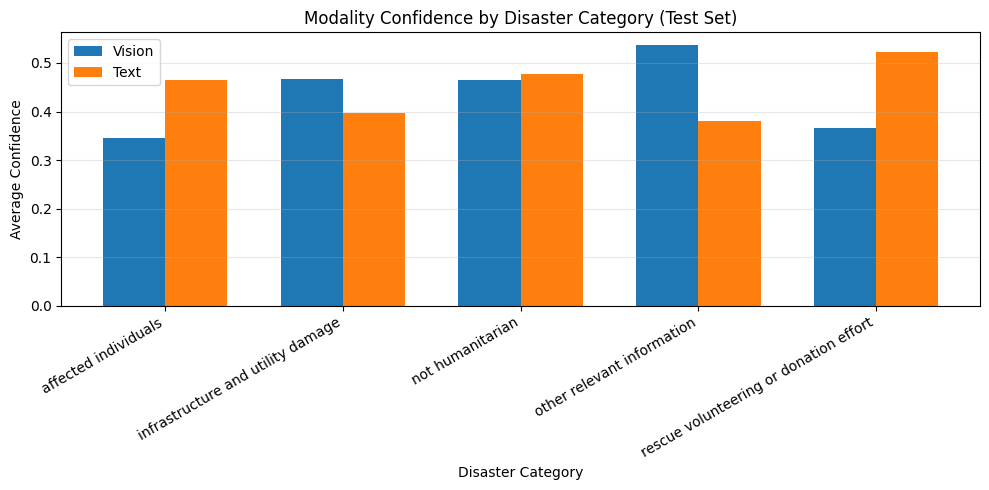


📊 Modality Confidence Summary:


In [114]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

# --------------------------------------------
# Model already loaded via state_dict (above)
# --------------------------------------------

class_confidences = {
    cls: {"vision": [], "text": []}
    for cls in label_encoder.classes_
}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Analyzing Modality Confidence"):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"]

        # IMPORTANT: keyword args
        _, attention_info = model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_attention=True
        )

        vision_conf = attention_info["vision_conf"].cpu().numpy()
        text_conf = attention_info["text_conf"].cpu().numpy()

        for i, label in enumerate(labels):
            cls = label_encoder.classes_[label]
            class_confidences[cls]["vision"].append(vision_conf[i])
            class_confidences[cls]["text"].append(text_conf[i])


# --------------------------------------------
# Plot (conference-ready)
# --------------------------------------------
classes = list(class_confidences.keys())
vision_means = [np.mean(class_confidences[c]["vision"]) for c in classes]
text_means   = [np.mean(class_confidences[c]["text"]) for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, vision_means, width, label="Vision")
plt.bar(x + width/2, text_means, width, label="Text")

plt.xlabel("Disaster Category")
plt.ylabel("Average Confidence")
plt.title("Modality Confidence by Disaster Category (Test Set)")
plt.xticks(x, [c.replace("_", " ") for c in classes], rotation=30, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("confidence_by_class.png", dpi=300)
plt.show()


# --------------------------------------------
# Print summary (for paper text)
# --------------------------------------------
print("\n📊 Modality Confidence Summary:")
